   Student_ID    Student_Name  Study_Hours  Attendance  Marks   Pass
0        S001     Mohit Gupta         10.8        50.6   97.0   True
1        S002   Vivaan Kapoor          7.6        62.2   70.0   True
2        S003     Aarush Shah         11.1        94.3   76.0   True
3        S004     Dhruv Kumar          2.0        60.2  100.0   True
5        S006    Karan Kapoor          1.5        73.0   48.0  False
6        S007     Deepak Nair          4.6        98.3   59.0  False
7        S008       Sai Reddy          5.3        60.3  -20.0  False
8        S009      Riya Verma          4.0        82.3   29.0  False
10       S011     Pranav Shah          4.9        60.1   56.0  False
11       S012     Shreya Iyer          4.1        85.1   66.0   True
12       S013     Vivaan Nair          7.0        66.8   86.0   True
13       S014  Advik Malhotra          2.6       115.0   97.0   True
14       S015  Rahul Malhotra          9.8        80.3   62.0   True
15       S016   Pooja Agarwal     

C:\Users\USER\AppData\Local\Temp\ipykernel_18548\307888147.py:51: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(var_data, vert=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_18548\307888147.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


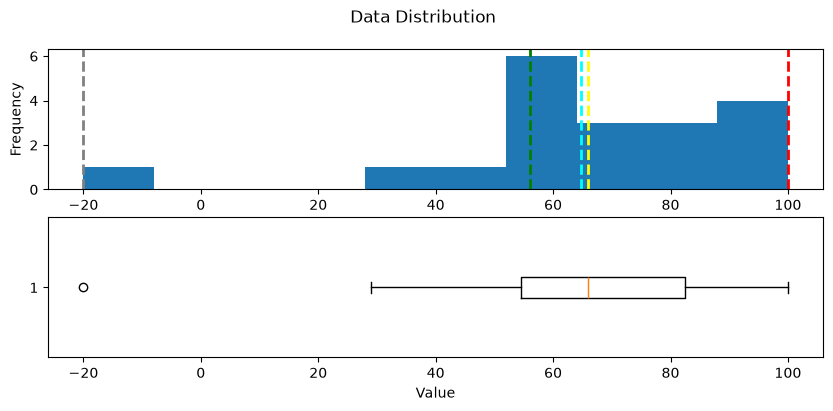

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

# Load the data from a text file 
url = "https://raw.githubusercontent.com/mahaveergautamji/Data-Project/main/data/student_dataset_v2.csv"
df_student = pd.read_csv(url, delimiter=',', header='infer')
df_student = df_student.head(22)

# Remove any rows with missing data
df_student = df_student.dropna(axis=0, how='any')

# Calculate who passed assuming '60' is the Mark needed to pass
passes = pd.Series(df_student['Marks'] >= 60)

# Save who passed to the Pandas dataframe 
df_student = pd.concat([df_student, passes.rename("Pass")], axis=1)

# Print the result out into this notebook 
print(df_student)


# Create a function we can re-use
def show_distribution(var_data):

    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mode_val = var_data.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}')


    # Create a figure for 2 subplots (2 rows, 1 column)
    fig, ax = plt.subplots(2, 1, figsize=(10, 4))

    # plot the histogram
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')

    # Add lines for the mean, median, and mode 
    ax[0].axvline(x=min_val, color='grey', linestyle='dashed', linewidth=2)
    ax[0].axvline(x=max_val, color='red', linestyle='dashed', linewidth=2)
    ax[0].axvline(x=mean_val, color='cyan', linestyle='dashed', linewidth=2)
    ax[0].axvline(x=med_val, color='yellow', linestyle='dashed', linewidth=2)
    ax[0].axvline(x=mode_val, color='green', linestyle='dashed', linewidth=2)


    # Plot the boxplot
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')

    # Add a title to the Figure
    fig.suptitle('Data Distribution')

    # Show the figure
    fig.show()


show_distribution(df_student['Marks'])

Minimum:{:.2f}
Mean:{:.2f}
Median:{:.2f}
Mode:{:.2f}
Maximum:{:.2f}


C:\Users\USER\AppData\Local\Temp\ipykernel_18548\307888147.py:51: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(var_data, vert=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_18548\307888147.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


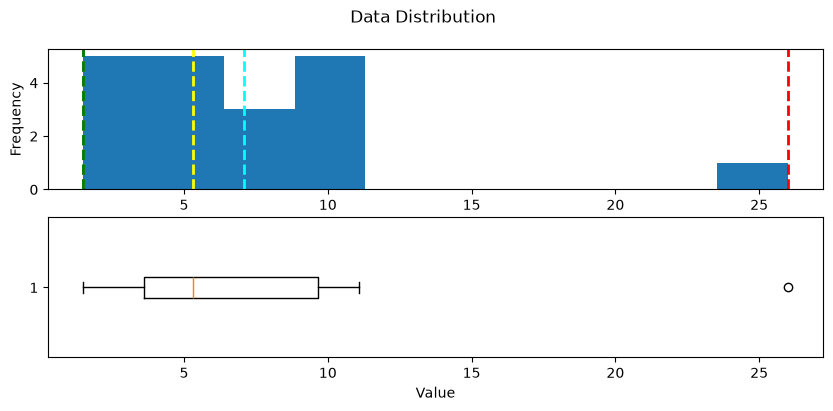

In [2]:
show_distribution(df_student['Study_Hours'])

Minimum:{:.2f}
Mean:{:.2f}
Median:{:.2f}
Mode:{:.2f}
Maximum:{:.2f}


C:\Users\USER\AppData\Local\Temp\ipykernel_18548\307888147.py:51: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(var_data, vert=False)
C:\Users\USER\AppData\Local\Temp\ipykernel_18548\307888147.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


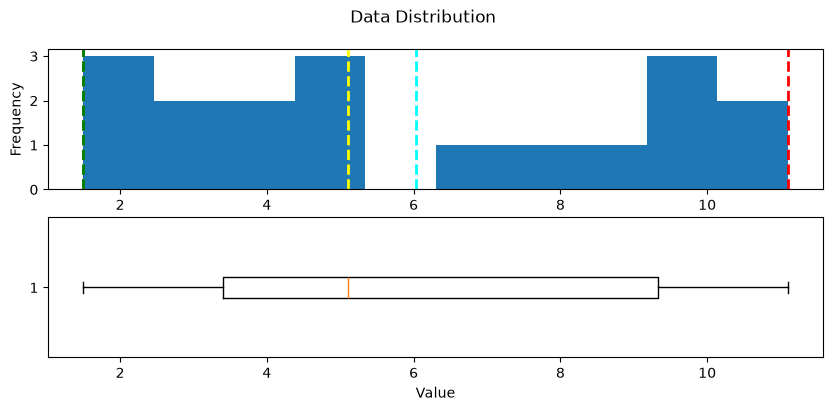

In [3]:
col = df_student[df_student.Study_Hours<25]['Study_Hours']
show_distribution(col)

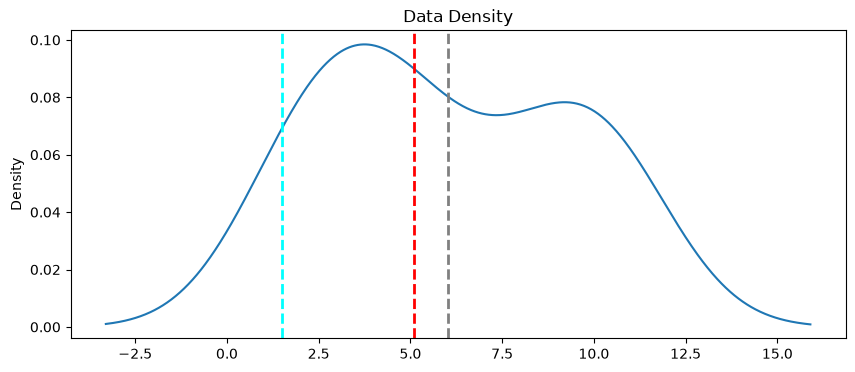

In [4]:
def show_density(var_data):
    fig = plt.figure(figsize=(10,4))

    # Plot density
    var_data.plot.density()

    # Add titles and labels
    plt.title('Data Density')

    # Show the mean, median, and mode
    plt.axvline(x=var_data.mean(), color='grey', linestyle='dashed', linewidth=2)
    plt.axvline(x=var_data.median(), color='red', linestyle='dashed', linewidth=2)
    plt.axvline(x=var_data.mode()[0], color='cyan', linestyle='dashed', linewidth=2)

    # show the figure 
    plt.show()

# Get the density of Study_Hours
show_density(col)

In [5]:
import math
mean = df_student.Study_Hours.mean()
variance = 0

for hours in df_student.Study_Hours:
    variance = variance + ((mean - hours)**2)

variance = variance/df_student.shape[0]

std = math.sqrt(variance)

std

5.4549121424633835

In [6]:
for col_name in ['Marks', 'Study_Hours']:
    col = df_student[col_name]
    rng = col.max() - col.min()
    var = col.var()
    std = col.std()
    print(f'\n{col_name}:\n - Range: {rng}\n - Variance: {var}\n - Std.Dev: {std}')


Marks:
 - Range: 120.0
 - Variance: 789.2046783625731
 - Std.Dev: 28.092786945452264

Study_Hours:
 - Range: 24.5
 - Variance: 31.40918128654971
 - Std.Dev: 5.604389465994464


In [7]:
print(f'68% OF marks will fall between {df_student.Marks.mean() - df_student.Marks.std()} and {df_student.Marks.mean() + df_student.Marks.std()}')

68% OF marks will fall between 36.644055159810904 and 92.82962905071543


In [8]:
df_student.describe()

,Study_Hours,Attendance,Marks
count,19.000000,19.000000,19.000000
mean,7.084211,73.921053,64.736842
std,5.604389,17.409945,28.092787
min,1.500000,50.100000,-20.000000
25%,3.600000,60.250000,54.500000
50%,5.300000,73.000000,66.000000
75%,9.650000,83.700000,82.500000
max,26.000000,115.000000,100.000000


In [9]:
df_sample = df_student[df_student.Study_Hours>1]
df_sample

,Student_ID,Student_Name,Study_Hours,Attendance,Marks,Pass
0,S001,Mohit Gupta,10.8,50.6,97.0,True
1,S002,Vivaan Kapoor,7.6,62.2,70.0,True
2,S003,Aarush Shah,11.1,94.3,76.0,True
3,S004,Dhruv Kumar,2.0,60.2,100.0,True
5,S006,Karan Kapoor,1.5,73.0,48.0,False
6,S007,Deepak Nair,4.6,98.3,59.0,False
7,S008,Sai Reddy,5.3,60.3,-20.0,False
8,S009,Riya Verma,4.0,82.3,29.0,False
10,S011,Pranav Shah,4.9,60.1,56.0,False
11,S012,Shreya Iyer,4.1,85.1,66.0,True


<Axes: title={'center': 'Study_Hours'}, xlabel='Pass'>

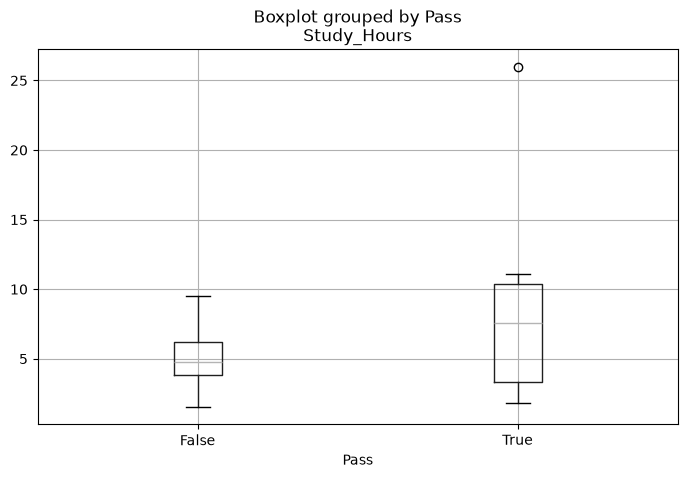

In [10]:
df_sample.boxplot(column='Study_Hours', by='Pass', figsize=(8, 5))

<Axes: xlabel='Student_Name'>

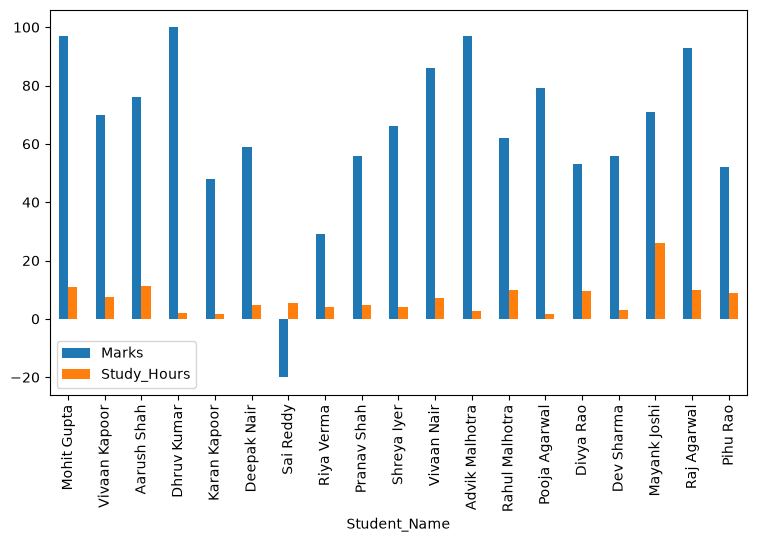

In [11]:
df_sample.plot.bar(x='Student_Name', y=['Marks', 'Study_Hours'], figsize=(9, 5))

<Axes: xlabel='Student_Name'>

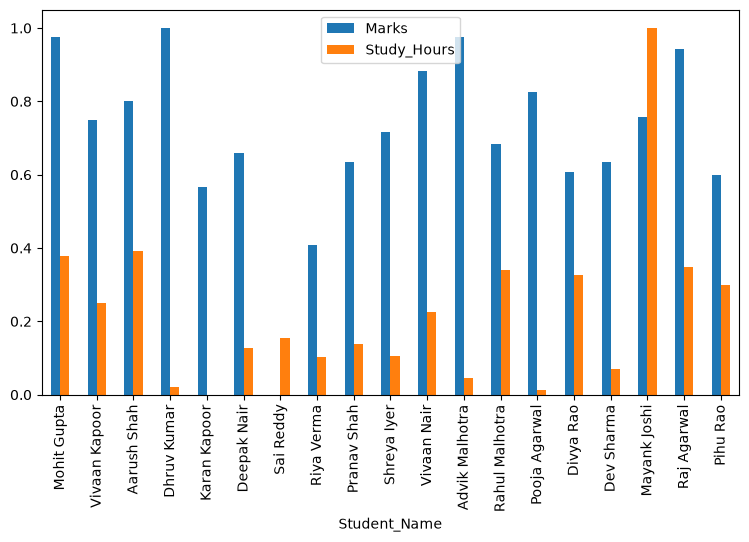

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df_sample[['Student_Name', 'Marks', 'Study_Hours']].copy()

df_normalized[['Marks', 'Study_Hours']] = scaler.fit_transform(df_normalized[['Marks', 'Study_Hours']])

df_normalized.plot(x='Student_Name', y=['Marks', 'Study_Hours'], kind='bar', figsize=(9, 5))

In [16]:
df_normalized.Marks.corr(df_normalized.Study_Hours)

np.float64(0.11585188186947679)

<Axes: title={'center': 'Study Time vs Marks'}, xlabel='Study_Hours', ylabel='Marks'>

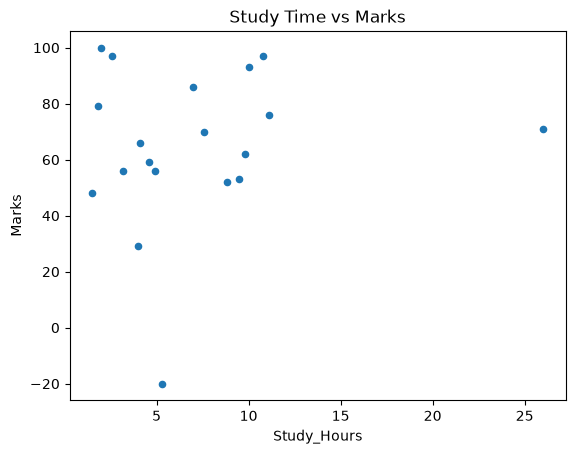

In [18]:
df_sample.plot.scatter(title='Study Time vs Marks', x='Study_Hours', y='Marks')

In [ ]:
y = mx + b

f(x)

error = y - f(x) ** 2

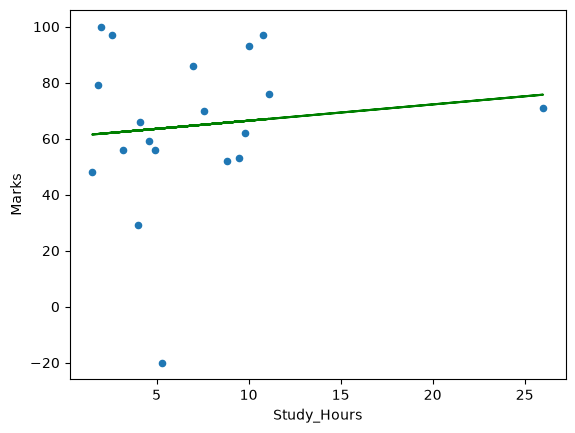

0.5807237798758883 60.6228725909845


In [24]:
from scipy import stats

df_regression = df_sample[['Marks', 'Study_Hours']].copy()

m, b, r, p, se = stats.linregress(df_regression['Study_Hours'], df_regression['Marks'])

df_regression['fx'] = (m * df_regression['Study_Hours']) + b

df_regression['error'] = df_regression['fx'] - df_regression['Marks']

df_regression.plot.scatter(x='Study_Hours', y='Marks')

plt.plot(df_regression['Study_Hours'], df_regression['fx'], color='green')

plt.show()

print(m,b)

In [26]:
def predict(x):
    m = 0.58072377
    b = 60.62287259
    return m*x + b

prediction = predict(24)

prediction

74.56024307